#Assignment on Statistics

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('/content/drive/MyDrive/IIT Palakkad Advanced AI/Data/StudentsPerformance.csv')

In [26]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some high school,free/reduced,none,0,17,10
1,female,group B,high school,free/reduced,none,8,24,23
2,female,group B,some high school,free/reduced,none,18,32,28
3,female,group B,some college,standard,none,11,38,32
4,female,group C,some college,free/reduced,none,22,39,33


##1. Calculate the mean, median, and mode for the math, reading, and writing scores.

In [27]:
# Mean
mean_scores = df[['math score', 'reading score', 'writing score']].mean()
print("Mean Scores:\n", mean_scores)

# Median
median_scores = df[['math score', 'reading score', 'writing score']].median()
print("\nMedian Scores:\n", median_scores)

# Mode
mode_scores = df[['math score', 'reading score', 'writing score']].mode()
print("\nMode Scores:\n", mode_scores)

Mean Scores:
 math score       66.001
reading score    69.195
writing score    68.119
dtype: float64

Median Scores:
 math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Mode Scores:
    math score  reading score  writing score
0          65             72             74


##2. Determine the range, variance, and standard deviation for each score category.

In [28]:
# Selecting score columns
scores = df[['math score', 'reading score', 'writing score']]

# Range (max - min)
range_scores = scores.max() - scores.min()
print("Range:\n", range_scores)

# Variance
variance_scores = scores.var()
print("\nVariance:\n", variance_scores)

# Standard Deviation
std_dev_scores = scores.std()
print("\nStandard Deviation:\n", std_dev_scores)

Range:
 math score       100
reading score     83
writing score     90
dtype: int64

Variance:
 math score       242.411410
reading score    216.279254
writing score    231.842682
dtype: float64

Standard Deviation:
 math score       15.569567
reading score    14.706436
writing score    15.226381
dtype: float64


##3. Identify the mean, median, and mode of math scores for students with different parental education levels.

In [29]:
# Group by parental level of education
grouped = df.groupby('parental level of education')['math score']

# Mean
mean_math = grouped.mean()
print("Mean Math Score:\n", mean_math)

# Median
median_math = grouped.median()
print("\nMedian Math Score:\n", median_math)

# Mode (special handling needed)
mode_math = grouped.apply(lambda x: x.mode())
print("\nMode Math Score:\n", mode_math)

Mean Math Score:
 parental level of education
associate's degree    67.977477
bachelor's degree     69.288136
high school           61.821429
master's degree       70.254237
some college          67.128319
some high school      63.134078
Name: math score, dtype: float64

Median Math Score:
 parental level of education
associate's degree    67.0
bachelor's degree     68.0
high school           63.0
master's degree       73.0
some college          68.0
some high school      65.0
Name: math score, dtype: float64

Mode Math Score:
 parental level of education   
associate's degree           0    65
bachelor's degree            0    63
                             1    65
                             2    66
high school                  0    57
                             1    66
master's degree              0    79
                             1    81
some college                 0    69
some high school             0    59
                             1    65
Name: math score, dtype: int

##4. Compare the mean scores of students who took the test preparation course versus those who didn’t

In [30]:
# Group by test preparation course
grouped_prep = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']]

# Calculate mean scores
mean_scores_prep = grouped_prep.mean()

print("Mean Scores based on Test Preparation Course:\n")
print(mean_scores_prep)

Mean Scores based on Test Preparation Course:

                         math score  reading score  writing score
test preparation course                                          
completed                  69.96648      74.175978      74.684358
none                       63.78972      66.417445      64.457944


<Axes: title={'center': 'Mean Scores by Test Preparation Course'}, xlabel='test preparation course'>

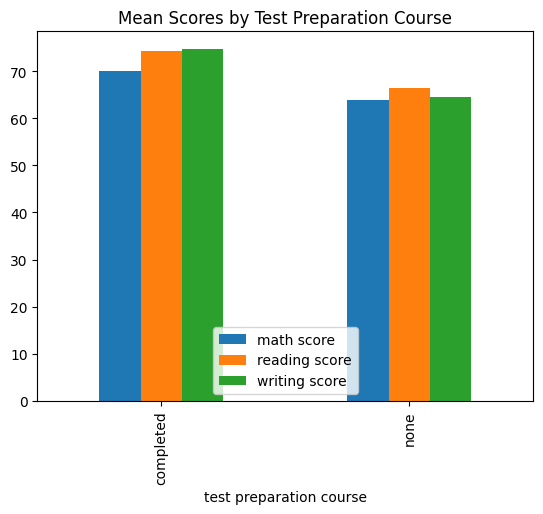

In [31]:
mean_scores_prep.plot(kind='bar', title='Mean Scores by Test Preparation Course')

##5. Calculate the interquartile range (IQR) for each score category

In [32]:
# Selecting score columns
scores = df[['math score', 'reading score', 'writing score']]

# Calculate Q1 and Q3
Q1 = scores.quantile(0.25)
Q3 = scores.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:\n", Q1)
print("\nQ3:\n", Q3)
print("\nInterquartile Range (IQR):\n", IQR)

Q1:
 math score       57.0
reading score    59.0
writing score    58.0
Name: 0.25, dtype: float64

Q3:
 math score       77.00
reading score    79.25
writing score    79.00
Name: 0.75, dtype: float64

Interquartile Range (IQR):
 math score       20.00
reading score    20.25
writing score    21.00
dtype: float64


##6. Determine the standard deviation for math scores by lunch type (free/reduced vs. standard).

In [33]:
# Group by lunch type
grouped_lunch = df.groupby('lunch')['math score']

# Calculate standard deviation
std_lunch = grouped_lunch.std()

print("Standard Deviation of Math Scores by Lunch Type:\n")
print(std_lunch)

Standard Deviation of Math Scores by Lunch Type:

lunch
free/reduced    15.882442
standard        13.804560
Name: math score, dtype: float64


<Axes: title={'center': 'Std Dev of Math Scores by Lunch Type'}, xlabel='lunch'>

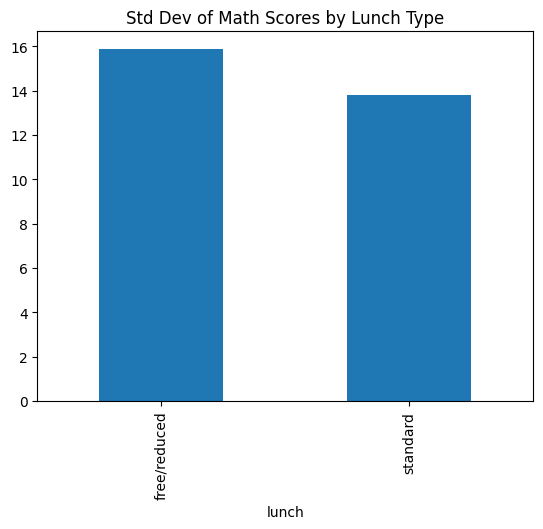

In [34]:
std_lunch.plot(kind='bar', title='Std Dev of Math Scores by Lunch Type')

##7. Find the correlation coefficient between math and reading scores, and then between reading and writing scores.

In [35]:
# Correlation between math and reading
corr_math_reading = df['math score'].corr(df['reading score'])

# Correlation between reading and writing
corr_reading_writing = df['reading score'].corr(df['writing score'])

print("Correlation (Math vs Reading):", corr_math_reading)
print("Correlation (Reading vs Writing):", corr_reading_writing)

Correlation (Math vs Reading): 0.8149368617648359
Correlation (Reading vs Writing): 0.953178417390664


In [36]:
# Correlation matrix
corr_matrix = df[['math score', 'reading score', 'writing score']].corr()
print(corr_matrix)

               math score  reading score  writing score
math score       1.000000       0.814937       0.797158
reading score    0.814937       1.000000       0.953178
writing score    0.797158       0.953178       1.000000


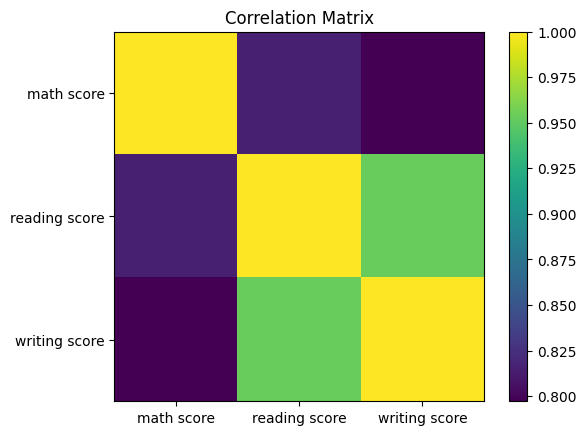

In [37]:
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

##8. Interpret the strength and direction of the correlation. What might this suggest about the relationship between different scores?

The correlation between the scores is positive, which means that as one score increases, the other scores also tend to increase.

*   The correlation between math and reading is moderate to strong, showing that students who do well in math often do well in reading.
*   The correlation between reading and writing is very strong, meaning students who score high in reading almost always score high in writing.

This suggests that reading and writing skills are closely related, while math is somewhat related but depends on different abilities.

##9. Calculate the covariance between math and reading scores. How does it compare with the correlation? What does it suggest?

In [38]:
# Covariance between math and reading
cov_math_reading = df['math score'].cov(df['reading score'])

print("Covariance (Math vs Reading):", cov_math_reading)

Covariance (Math vs Reading): 186.59840340340335


##10. Z-Test: Assume the national average math score is 50. Use a one-sample z-test to test if this sample's average math score is significantly different from the national average.


In [39]:
from scipy import stats

# Sample data
math_scores = df['math score']

# Given population mean
mu = 50

# Sample statistics
sample_mean = np.mean(math_scores)
sample_std = np.std(math_scores, ddof=1)
n = len(math_scores)

# Calculate Z-score
z_score = (sample_mean - mu) / (sample_std / np.sqrt(n))

# Calculate p-value (two-tailed)
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Sample Mean:", sample_mean)
print("Z-Score:", z_score)
print("P-Value:", p_value)

Sample Mean: 66.001
Z-Score: 32.49904476017308
P-Value: 0.0


##11. T-Test: Compare the reading scores between students with different lunch types(free/reduced vs. standard) to test if there is a significant difference.

In [40]:
from scipy import stats

# Split data into two groups
standard = df[df['lunch'] == 'standard']['reading score']
free_reduced = df[df['lunch'] == 'free/reduced']['reading score']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(standard, free_reduced)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 7.492798943109684
P-Value: 1.4829967008771313e-13


##12. F-Test: Check if the variances of math scores differ significantly between students with and without test preparation.

In [41]:
from scipy import stats

# Split groups based on test preparation
completed = df[df['test preparation course'] == 'completed']['math score']
none = df[df['test preparation course'] == 'none']['math score']

# Calculate variances
var_completed = np.var(completed, ddof=1)
var_none = np.var(none, ddof=1)

# Compute F-statistic (larger variance / smaller variance)
F = var_completed / var_none if var_completed > var_none else var_none / var_completed

# Degrees of freedom
df1 = len(completed) - 1
df2 = len(none) - 1

# Calculate p-value (two-tailed)
p_value = 2 * (1 - stats.f.cdf(F, df1, df2))

print("Variance (Completed):", var_completed)
print("Variance (None):", var_none)
print("F-Statistic:", F)
print("P-Value:", p_value)

Variance (Completed): 210.8840273539583
Variance (None): 246.66866169973943
F-Statistic: 1.1696886900102605
P-Value: 0.08951037679012552
